### Практика решения задач

1. Постройте гистограмму распределения годов выхода фильмов.
2. Найдите год с минимальным количеством фильмов.
3. Постройте столбчатую диаграмму с топ-7 стран по количеству произведенных фильмов.
4. Найдите год с самым высоким средним рейтингом.
5. Сравните средний рейтинг США и Франции (сохраните обе величины с точностью до двух знаков после запятой)
6. Постройте линейный график того, как менялся средний рейтинг для фильмов до 2000 года.

In [1]:
### Импорты библиотек
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Импорт данных

df = pd.read_csv("../kinopoisk-top250.csv")
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   rating        250 non-null    int64  
 1   movie         250 non-null    str    
 2   year          250 non-null    int64  
 3   country       250 non-null    str    
 4   rating_ball   250 non-null    float64
 5   overview      250 non-null    str    
 6   director      250 non-null    str    
 7   screenwriter  250 non-null    str    
 8   actors        250 non-null    str    
 9   url_logo      250 non-null    str    
dtypes: float64(1), int64(2), str(7)
memory usage: 19.7 KB


(array([ 3.,  3.,  1., 12., 15., 23., 34., 48., 76., 35.]),
 array([1921. , 1930.8, 1940.6, 1950.4, 1960.2, 1970. , 1979.8, 1989.6,
        1999.4, 2009.2, 2019. ]),
 <BarContainer object of 10 artists>)

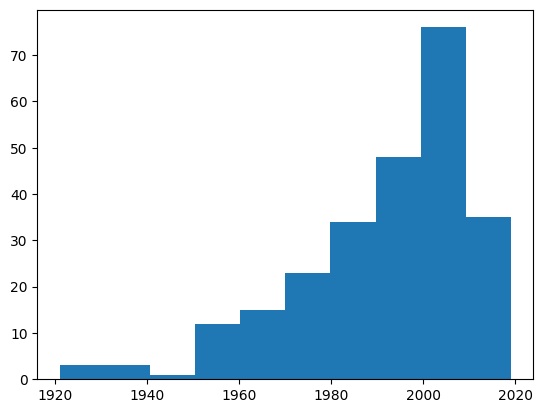

In [7]:
# гистограмма распределения годов выхода фильмов
plt.hist(df['year'], bins=10)

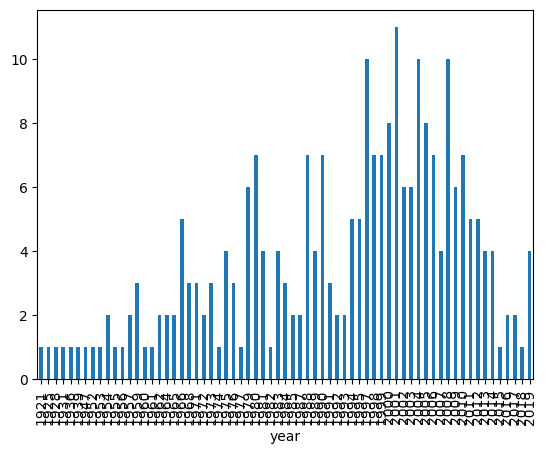

year
1921    1
1925    1
1928    1
1931    1
1936    1
1939    1
1947    1
1952    1
1953    1
1954    2
dtype: int64

In [8]:
# год с минимальным количеством фильмов

df['year'] = pd.to_numeric(df['year'], errors='coerce').astype("Int64")
# df.info()
movies_per_year = df.groupby('year').size()
movies_per_year.plot(kind='bar')
plt.show()
display(movies_per_year.head(10))

In [9]:
min_year = movies_per_year.idxmin()  # Первый из минимальных. Если нужны все - .min()
min_count = movies_per_year[min_year]

print(f"Год с минимальным количеством фильмов: {min_year}, количество фильмов: {min_count}")

Год с минимальным количеством фильмов: 1921, количество фильмов: 1


country
США               147
СССР               41
Великобритания     15
Франция             8
Япония              7
Италия              7
Германия            6
dtype: int64

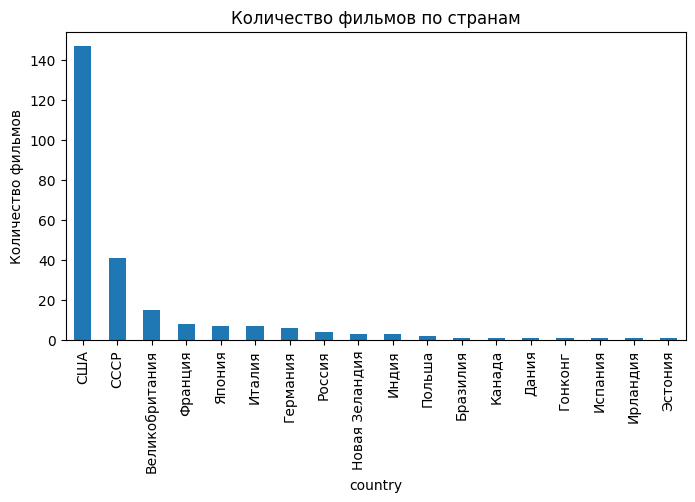

In [ ]:
# столбчатая диаграмма с топ-7 стран по количеству произведенных фильмов

countries_by_movie_count = df.groupby("country").size()  # .reset_index(name="count")  # в DataFrame
countries_by_movie_count = countries_by_movie_count.sort_values(ascending=False)
display(countries_by_movie_count.head(7))

plt.figure(figsize=(8, 4))
countries_by_movie_count.plot(kind="bar")
plt.title("Количество фильмов по странам")
plt.ylabel("Количество фильмов")
plt.show()

In [11]:
# год с самым высоким средним рейтингом
max_rating = df['rating_ball'].max()
max_rating_year = df[df['rating_ball'] == max_rating]['year'].tolist()
print(f"Максимальный рейтинг {max_rating} в {max_rating_year} году.")

Максимальный рейтинг 9.111 в [1994] году.
